In [ ]:
import os
import requests
import numpy as np
import chromadb
import torch
import pandas as pd
import uuid
from PIL import Image, ImageSequence
from io import BytesIO
from transformers import CLIPProcessor, CLIPModel
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

/home/owen/Projects/local-rag/venv-notebooks/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


##### Normalize and clean csv data

In [ ]:
def generate_ids_in_csv(csv_path):
    df = pd.read_csv(csv_path)

    if "id" not in df.columns:
        df["id"] = None
    
    mask = df["id"].isna()
    df.loc[mask, "id"] = [str(uuid.uuid4()) for _ in range(mask.sum())]
    df.to_csv(csv_path, index=False)

In [2]:
def deduplicate_urls(csv_path):
    df = pd.read_csv(csv_path)
    df["item_id"] = df["url"].str.extract(r"(items/.*)")
    return df.drop_duplicates(subset=["item_id"]).drop(columns=["item_id"])

In [3]:
csv_path = "avatars.csv"

In [151]:
generate_ids_in_csv(csv_path)

In [4]:
df = deduplicate_urls(csv_path)

In [5]:
df.columns

Index(['url', 'date_scraped', 'id'], dtype='str')

In [5]:
df.head(2)

,url,date_scraped,id
0,https://shared.akamai.steamstatic.com/communit...,2026-05-09T14:22:56.931538+00:00,86e56e5b-cf8f-4a4b-ad93-f1737026246e
1,https://shared.akamai.steamstatic.com/communit...,2026-05-09T14:22:56.931538+00:00,892342a7-b3cb-49b5-98f1-2fa39e3822d6


In [6]:
len(df)

2578

##### Create CLIP model and Chroma collection

In [7]:
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 38469.21it/s]


In [8]:
client = chromadb.PersistentClient(path="steam_avatars_db")

```text
"hnsw:space"            # Distance metric
"hnsw:M"                # Connections per node
"hnsw:ef_construction"  # Build-time search width
"hnsw:ef"               # Query-time search width
"hnsw:num_threads"      # Parallelism
"hnsw:resize_factor"    # Index growth factor
"hnsw:sync_threshold"   # Disk sync frequency
"hnsw:batch_size"       # Upsert batch size
```

```text
1. CREATE         space, ef_construction=800, max_neighbors=64  (set and forget)
        ↓
2. BULK INSERT    num_threads=8, sync_threshold=2000, batch_size=512
        ↓
3. BUILD DONE     sync_threshold=1000 (back to safe default)
        ↓
4. QUERY TUNING   ef_search: start 200 → drop to 100 if too slow
        ↓
5. PROD           num_threads=2-4 if sharing CPU with other services
```

In [16]:
collection = client.get_or_create_collection(
    name="steam_avatars_collection",
    configuration={
        "hnsw": {
            "space": "cosine",
            "ef_construction": 800,
            "max_neighbors": 64,
            "ef_search": 200,
            "num_threads": 8,
            "resize_factor": 1.2,
            "batch_size": 512,
            "sync_threshold": 2000,
        }
    }
)

##### Cache images
_We shouldn't ping any endpoint more than once_

In [155]:
def convert_url_to_img(url):
    response = requests.get(url, timeout=30)
    img = Image.open(BytesIO(response.content))
    return img

In [156]:
images = {}

In [ ]:
def get_session():
    session = requests.Session()
    retry_strategy = Retry(
        total=5,                                    # Total number of attempts
        backoff_factor=2,                           # Wait 2s, 4s, 8s, 16s... between retries
        status_forcelist=[429, 500, 502, 503, 504], # Retry on these server errors
        allowed_methods=["HEAD", "GET", "OPTIONS"]
    )
    adapter = HTTPAdapter(max_retries=retry_strategy)
    session.mount("https://", adapter)
    session.mount("http://", adapter)
    return session

In [158]:
def convert_url_to_img(url, session):
    try:
        response = session.get(url, timeout=60) 
        response.raise_for_status()
        return Image.open(BytesIO(response.content))
    except Exception as e:
        print(f"Permanent failure for {url}: {e}")
        return None

In [159]:
images = {}
session = get_session()

for i in range(len(df)):
    record = df.iloc[i]
    img = convert_url_to_img(record["url"], session)
    if img:
        images[record["id"]] = img

In [15]:
list(images.values())[1].format

'GIF'

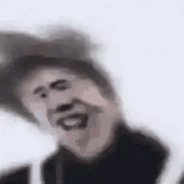

In [16]:
list(images.values())[1]

##### Save images to a folder

In [ ]:
saved_ids = [file.rstrip(".gif") for file in os.listdir("images")]
new_images = {id: img for id, img in images.items() if id not in saved_ids}

for id, img in new_images.items():
    file_path = os.path.join("images", f"{id}.gif")    
    if getattr(img, "is_animated", False):
        frames = [frame.copy() for frame in ImageSequence.Iterator(img)]        
        frames[0].save(
            file_path,
            save_all=True,
            append_images=frames[1:],
            duration=img.info.get('duration', 100), # original speed
            loop=img.info.get('loop', 0) # keep in the loop
        )
    else:
        img.save(file_path)

##### Load images from a folder

In [13]:
def load_images_to_dict(folder_path):
    images = {}
    
    for filename in os.listdir(folder_path):
        name, ext = os.path.splitext(filename)
        file_path = os.path.join(folder_path, filename)
        
        try:
            img = Image.open(file_path)
            
            # We use .copy() because Image.open() is lazy and  might keep the file handle open.
            images[name] = img.copy()
        except Exception as e:
            print(f"Could not load {filename}: {e}")
                
    return images

In [14]:
images = load_images_to_dict(folder_path="images")

##### Create embeddings from images

In [17]:
# Move model to GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

CLIPModel(
  (text_model): CLIPTextModel(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05, eleme

In [ ]:
def convert_img_to_embeddings(image_list):
    """
    Processes a list of images and returns a list of normalized embeddings.
    """
    inputs = processor(images=image_list, return_tensors="pt", padding=True).to(device)

    with torch.no_grad():
        outputs = model.get_image_features(**inputs)
        
        if not isinstance(outputs, torch.Tensor):
            embeddings = getattr(outputs, "image_embeds", None)
            if embeddings is None:
                embeddings = getattr(outputs, "pooler_output", outputs[0])
        else:
            embeddings = outputs

        norm_embeddings = embeddings / embeddings.norm(p=2, dim=-1, keepdim=True)

    return norm_embeddings.cpu().numpy().tolist()

In [19]:
batch_size = 32

for i in range(0, len(df), batch_size):
    batch_df = df.iloc[i : i + batch_size]
    
    batch_ids = []
    batch_metadatas = []
    batch_imgs = []

    for _, record in batch_df.iterrows():
        img_id = record["id"]
        url = record["url"]

        batch_ids.append(str(img_id))
        batch_metadatas.append({
            "url": url, 
            "type": url.split(".")[-1]
        })
        batch_imgs.append(images[img_id])

    embeddings_list = convert_img_to_embeddings(batch_imgs)

    collection.add(
        embeddings=embeddings_list,
        metadatas=batch_metadatas,
        ids=batch_ids
    )

print(f"Successfully processed {len(df)} images into the collection.")

Successfully processed 2578 images into the collection.


##### Test

In [10]:
def search(text, n_results=5):
    inputs = processor(text=[text], return_tensors="pt", padding=True)

    with torch.no_grad():
        outputs = model.get_text_features(**inputs)

    if hasattr(outputs, "pooler_output"):
        emb = outputs.pooler_output
    else:
        emb = outputs

    emb = emb[0] if emb.ndim > 1 else emb
    emb = emb / emb.norm(p=2)
    emb = emb.cpu().numpy().astype(np.float32)

    results = collection.query(query_embeddings=[emb.tolist()], n_results=n_results)
    return [result["url"] for result in results["metadatas"][0]] + results["distances"]

In [20]:
search("skeleton")

['https://shared.fastly.steamstatic.com/community_assets/images/items/220820/0f16dd1c402ebe796e4237fc0c047362444f924d.gif',
 'https://shared.akamai.steamstatic.com/community_assets/images/items/1845910/ebd97327779af08c3f731f85762b55a8c0299bd6.gif',
 'https://shared.akamai.steamstatic.com/community_assets/images/items/579720/14104ab4737413b2a495b2ab0cd1191933570e99.gif',
 'https://shared.akamai.steamstatic.com/community_assets/images/items/3257180/edf6cced80a17a753b0efd089ffad8b3932e100f.gif',
 'https://shared.fastly.steamstatic.com/community_assets/images/items/2218750/2ffb7cb545ad66b8506ab6a02e74e380502b5978.gif',
 [0.7060762643814087,
  0.711625874042511,
  0.7152889370918274,
  0.7230647802352905,
  0.7257593274116516]]

In [13]:
search("darkest dungeon")

['https://shared.akamai.steamstatic.com/community_assets/images/items/1850570/c87f2ceaeb16bad2d41f613d667edd22acf8d673.gif',
 'https://shared.akamai.steamstatic.com/community_assets/images/items/1940340/23759826491dbbaba18ddefb18dfea82c0b22cef.gif',
 'https://shared.akamai.steamstatic.com/community_assets/images/items/1940340/83e225ac0f2358da5f8fd7e39f4763b9d7316d24.gif',
 'https://shared.akamai.steamstatic.com/community_assets/images/items/262060/5c59ef08159fded4e7003667723c99bc24cd6e76.gif',
 'https://shared.fastly.steamstatic.com/community_assets/images/items/1940340/555d0697e8fa02963b5737f00fb15d456b45f5f2.gif',
 [0.6883703470230103,
  0.6923303008079529,
  0.6923400163650513,
  0.6927621364593506,
  0.6932394504547119]]

In [15]:
search("anime girl uwu")

['https://shared.fastly.steamstatic.com/community_assets/images/items/1299120/af7642ab8c177f82d64fc69af23d9e4b33ff1e8d.gif',
 'https://shared.akamai.steamstatic.com/community_assets/images/items/2543050/e884ca78dcef265c1dc33f18680ba9c5cec0b97a.gif',
 'https://shared.fastly.steamstatic.com/community_assets/images/items/1385730/9b963628af732a322561925cb43db0991ab098d1.gif',
 'https://shared.fastly.steamstatic.com/community_assets/images/items/2313020/ec747957231ddde6010a227318aff2002f05bb03.gif',
 'https://shared.fastly.steamstatic.com/community_assets/images/items/1299120/e96c3adbffa6e8c0217881261b777fd6274afbcc.gif',
 [0.6988298296928406,
  0.704649806022644,
  0.7047752737998962,
  0.7065085172653198,
  0.7067270278930664]]